# LF-CBM soft recall section (concepts instead of attributes)

This section mirrors the outputs of the attribute-based notebook, but replaces:

- **Attribute name** → **LF-CBM concept string**
- **Ground-truth y ∈ {0,1}** → **soft pseudo ground-truth weight**  \tilde P_{i,j} derived from CLIP similarity
- **Recall on positives** → **soft recall**: weighted average of predicted concept probability on pseudo-positive evidence

We still keep a binary notion of “positives” for matched-pair sampling:
- y_bin = 1[ \tilde P > 0 ]
so we can reuse the same matched-pair evaluation structure as the old notebook.

Outputs we will reproduce (old → new equivalents):

Old attribute notebook outputs:
1) per-attribute `info_df`  → per-concept `lf_info_df`
2) per-(attr,pair) `pairs_df` → per-(concept,pair) `lf_pairs_df`
3) per-(attr,species) `species_df` → per-(concept,species) `lf_species_df`
4) `summary` over attrs → `lf_summary` over concepts
5) `top_pairs(...)` tables → `top_pairs_lf(...)` tables

Note: there is no “test_acc” in the same sense, because we are not predicting human labels; we will report:
- **mean_soft_recall** (overall)
- **mean_gap** across matched species pairs (same meaning as before)
- (optional) **corr(pred, Ptilde)** as a sanity check.

For each attribute:

1. Train a linear probe on top of frozen visual features.
2. Evaluate the probe on held-out test images.
3. Group test images by species.
4. For pairs of species:
   - Subsample images so that both species have the same number of
     attribute-positive and attribute-negative examples.
   - Compute recall on attribute-positive images for each species.
5. Measure the recall gap between species.

## FIltering out Concepts formed before Species

In [1]:
import json
import random
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim


ROOT = Path("/scratch/network/cr7998/cv_emergence_project")
CUB  = ROOT / "data" / "CUB_200_2011"

FEAT_FINE = ROOT / "features" / "resnet50_cub_fine"     # or resnet50_cub
assert FEAT_FINE.exists()

ATTR_TXT = ROOT / "data" / "attributes.txt"   # attr_id -> attr_name like has_primary_color::yellow

BASE_FEAT = ROOT / "features" / "resnet50_cub_fine"
CBM_FEAT  = ROOT / "features" / "resnet50_cub_cbm_fine"

assert CUB.exists(), f"Missing CUB folder: {CUB}"
assert ATTR_TXT.exists(), f"Missing attributes.txt: {ATTR_TXT}"
assert BASE_FEAT.exists(), f"Missing baseline fine features: {BASE_FEAT}"
assert CBM_FEAT.exists(), f"Missing cbm fine features: {CBM_FEAT}"

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
def align_lf_to_feature_order(lf_image_ids: np.ndarray, lf_array: np.ndarray, feature_image_ids: list[int]):
    """
    Align lf_array (in LF ImageFolder order) to feature order (labels_*.pt order).
    Drops any feature_image_ids not present in lf_image_ids.

    Returns:
      kept_feature_image_ids: list[int] (feature order but only those present in LF)
      aligned_lf_array: np.ndarray (same first-dim length as kept_feature_image_ids)
      keep_feat_idx: np.ndarray indices into feature arrays to keep
    """
    lf_pos = {int(img_id): i for i, img_id in enumerate(lf_image_ids)}
    keep_feat_idx = []
    take_lf_idx = []

    for k, img_id in enumerate(feature_image_ids):
        j = lf_pos.get(int(img_id), None)
        if j is None:
            continue
        keep_feat_idx.append(k)
        take_lf_idx.append(j)

    keep_feat_idx = np.asarray(keep_feat_idx, dtype=int)
    take_lf_idx   = np.asarray(take_lf_idx, dtype=int)

    kept_feature_image_ids = [int(feature_image_ids[k]) for k in keep_feat_idx]
    aligned_lf_array = lf_array[take_lf_idx]
    return kept_feature_image_ids, aligned_lf_array, keep_feat_idx

## Finding Recall Gap

In [3]:
LFCBM_REPO = Path("/scratch/network/cr7998/Label-free-CBM/")         
LFCBM_RUN_DIR = LFCBM_REPO / "saved_models" / "cub_cbm_2026_02_06_11_37" 

assert LFCBM_REPO.exists(), f"Missing: {LFCBM_REPO}"
assert LFCBM_RUN_DIR.exists(), f"Missing: {LFCBM_RUN_DIR}"

# Allow importing lfcbm utils/data_utils/cbm if needed
if str(LFCBM_REPO) not in sys.path:
    sys.path.insert(0, str(LFCBM_REPO))

PM_SUFFIX = {"max": "_max", "avg": ""}

def lf_get_save_names(clip_name, target_name, target_layer, d_probe, concept_set, pool_mode, save_dir):
    """
    Local copy of LF-CBM utils.get_save_names so we don't import LF-CBM repo deps.
    """
    save_dir = str(save_dir)
    if str(target_name).startswith("clip_"):
        target_save_name = f"{save_dir}/{d_probe}_{str(target_name).replace('/', '')}.pt"
    else:
        target_save_name = f"{save_dir}/{d_probe}_{target_name}_{target_layer}{PM_SUFFIX[pool_mode]}.pt"
    clip_save_name = f"{save_dir}/{d_probe}_clip_{str(clip_name).replace('/', '')}.pt"
    concept_set_name = Path(concept_set).name.split(".")[0]
    text_save_name = f"{save_dir}/{concept_set_name}_{str(clip_name).replace('/', '')}.pt"
    return target_save_name, clip_save_name, text_save_name

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
def load_species_maps(cub_root: Path):
    classes = pd.read_csv(
        cub_root / "classes.txt",
        sep=r"\s+",
        header=None,
        names=["species_id", "class_name"],
        engine="python"
    )

    def pretty(name: str) -> str:
        return name.split(".", 1)[-1].replace("_", " ")

    return dict(zip(
        classes["species_id"].astype(int),
        classes["class_name"].map(pretty),
    ))

species_id_to_name = load_species_maps(CUB)

def spname(sid: int) -> str:
    return species_id_to_name.get(int(sid), f"species_{sid}")

In [5]:
def load_meta(cub_root: Path) -> pd.DataFrame:
    img_species = pd.read_csv(
        cub_root / "image_class_labels.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "species_id"],
        engine="python"
    )

    split_df = pd.read_csv(
        cub_root / "train_test_split.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "is_train"],
        engine="python"
    )

    meta = img_species.merge(split_df, on="image_id")
    meta["species_name"] = meta["species_id"].map(spname)
    return meta

meta = load_meta(CUB)

In [6]:
def load_image_attr_labels_robust(cub_root: Path) -> pd.DataFrame:
    path = cub_root / "attributes" / "image_attribute_labels.txt"
    rows = []

    with open(path, "r") as f:
        for line in f:
            toks = line.strip().split()
            if len(toks) < 4:
                continue
            rows.append((int(toks[0]), int(toks[1]), int(toks[2]), int(toks[3])))

    return pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])

img_attr_long = load_image_attr_labels_robust(CUB)

In [7]:
def load_attr_maps(attr_txt: Path):
    rows = []
    with open(attr_txt, "r") as f:
        for line in f:
            aid, name = line.strip().split(" ", 1)
            rows.append((int(aid), name))
    df = pd.DataFrame(rows, columns=["attr_id", "attr_name"])
    return df, dict(zip(df.attr_name, df.attr_id)), dict(zip(df.attr_id, df.attr_name))

attr_df, attr_name_to_id, attr_id_to_name = load_attr_maps(ATTR_TXT)

## Load LF-CBM run metadata + concept list

We load:
- `args.txt` to know which concept_set and backbone were used.
- `concepts.txt` which is the *final filtered* concept list used by the trained LF-CBM model.

We also load the initial concept set file referenced by args, because the saved CLIP text features correspond to that initial list, and we need to map initial → final indices.

In [8]:
# Load args from the trained LF-CBM directory
with open(LFCBM_RUN_DIR / "args.txt", "r") as f:
    lf_args = json.load(f)

with open(LFCBM_RUN_DIR / "concepts.txt", "r") as f:
    lf_concepts_final = [x.strip() for x in f.read().split("\n") if x.strip()]

print("Backbone:", lf_args["backbone"])
print("Feature layer:", lf_args["feature_layer"])
print("Clip name:", lf_args["clip_name"])
print("Concept set file:", lf_args["concept_set"])
print("Num final concepts:", len(lf_concepts_final))
print("Example concepts:", lf_concepts_final[:10])

Backbone: resnet50_cub_custom
Feature layer: layer4
Clip name: ViT-B/16
Concept set file: data/concept_sets/cub_filtered.txt
Num final concepts: 251
Example concepts: ['A black body', 'A blue sheen on the wings', 'A red eye', 'All-dark plumage', 'Glossy black wings', 'White wingtips', 'a Scarlet-red body', 'a black V on the back', 'a black and white barred tail', 'a black and white body']


## Build mapping: ImageFolder order → CUB image_id

LF-CBM uses `torchvision.datasets.ImageFolder(data/CUB/test)` ordering.
Your `meta` / attribute labels are keyed by `image_id` from CUB’s official files.

So we must align:
- the **row order** in LF-CBM’s saved activations (ImageFolder order)
with
- the CUB `image_id` values used in your `meta`.

We do this by using CUB’s `images.txt` which maps:
  image_id ↔ relative path like "001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg"

Then we reconstruct the ImageFolder relative paths and map them to image_id.

In [9]:
from torchvision import datasets

def load_images_txt_map(cub_root: Path):
    # CUB_200_2011/images.txt
    df = pd.read_csv(
        cub_root / "images.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "relpath"],
        engine="python"
    )
    rel_to_id = dict(zip(df["relpath"].astype(str), df["image_id"].astype(int)))
    return rel_to_id

rel_to_image_id = load_images_txt_map(CUB)

def get_imagefolder_image_ids(imagefolder_root: Path):
    ds = datasets.ImageFolder(imagefolder_root)  # transform irrelevant; we only use .samples
    relpaths = []
    for (abspath, _cls) in ds.samples:
        # Make relpath like CUB uses: "<class_folder>/<filename>"
        abspath = Path(abspath)
        rel = f"{abspath.parent.name}/{abspath.name}"
        relpaths.append(rel)

    image_ids = []
    missing = 0
    for rel in relpaths:
        if rel not in rel_to_image_id:
            missing += 1
            image_ids.append(-1)
        else:
            image_ids.append(rel_to_image_id[rel])
    image_ids = np.array(image_ids, dtype=int)

    assert missing == 0, f"{missing} ImageFolder paths not found in images.txt mapping"
    return image_ids

# LF-CBM datasets.ImageFolder roots (from its data_utils.py):
LFCBM_CUB_TEST = LFCBM_REPO / "data" / "CUB" / "test"
LFCBM_CUB_TRAIN = LFCBM_REPO / "data" / "CUB" / "train"

assert LFCBM_CUB_TEST.exists(), f"Missing: {LFCBM_CUB_TEST}"
assert LFCBM_CUB_TRAIN.exists(), f"Missing: {LFCBM_CUB_TRAIN}"

lf_ids_test = get_imagefolder_image_ids(LFCBM_CUB_TEST)
lf_ids_train = get_imagefolder_image_ids(LFCBM_CUB_TRAIN)

print("LF test ids range:", lf_ids_test.min(), lf_ids_test.max(), "n=", len(lf_ids_test))
print("LF train ids range:", lf_ids_train.min(), lf_ids_train.max(), "n=", len(lf_ids_train))

LF test ids range: 1 11788 n= 5790
LF train ids range: 2 11787 n= 5990


## Load LF-CBM concept activations `c(x)` (the bottleneck)

Your LF-CBM model stores:
- `W_c.pt`  (projection weights)
- `proj_mean.pt`, `proj_std.pt` (normalization used before final layer)

We will reproduce the exact LF-CBM bottleneck activations used for classification:
  c(x) = (W_c f(x) - mean) / std

Where f(x) are the backbone activations saved in `activation_dir` for the chosen `feature_layer`.

In [10]:
# Load LF-CBM learned projection and normalization
W_c = torch.load(LFCBM_RUN_DIR / "W_c.pt", map_location="cpu", weights_only=False)
proj_mean = torch.load(LFCBM_RUN_DIR / "proj_mean.pt", map_location="cpu", weights_only=False)
proj_std  = torch.load(LFCBM_RUN_DIR / "proj_std.pt", map_location="cpu", weights_only=False)

W_c = W_c.float()
proj_mean = proj_mean.float()
proj_std = proj_std.float()

print("W_c:", tuple(W_c.shape), "proj_mean:", tuple(proj_mean.shape), "proj_std:", tuple(proj_std.shape))
print("Num concepts implied:", W_c.shape[0], "==", len(lf_concepts_final))

W_c: (251, 2048) proj_mean: (1, 251) proj_std: (1, 251)
Num concepts implied: 251 == 251


## Load saved backbone activations for train/test and compute c(x)

LF-CBM saved activations with `utils.get_save_names(...)`.
We will use the same helper from LF-CBM repo to locate the `.pt` files, then compute:
- train_c: [N_train, M] bottleneck coords
- test_c : [N_test,  M] bottleneck coords

These are aligned to ImageFolder order, which we mapped to `image_id` arrays (`lf_ids_train`, `lf_ids_test`).

In [11]:
def resolve_lf_path(p: str | Path) -> Path:
    p = Path(p)
    # if already absolute, keep it
    if p.is_absolute():
        return p
    # otherwise treat as relative to LF-CBM repo root
    return (LFCBM_REPO / p).resolve()

concept_set_path = resolve_lf_path(lf_args["concept_set"])
assert concept_set_path.exists(), f"Missing concept_set: {concept_set_path}"

with open(concept_set_path, "r") as f:
    lf_concepts_initial = [x.strip() for x in f.read().split("\n") if x.strip()]

In [12]:
# Helper: load initial concept list (the file used to generate saved text features)
concept_set_path = resolve_lf_path(Path(lf_args["concept_set"]))
assert concept_set_path.exists(), f"Missing concept_set: {concept_set_path}"

with open(concept_set_path, "r") as f:
    lf_concepts_initial = [x.strip() for x in f.read().split("\n") if x.strip()]

# Map initial concept index by string
init_index = {c:i for i,c in enumerate(lf_concepts_initial)}

# Build column indices that correspond to final concepts
final_cols = []
missing = []
for c in lf_concepts_final:
    if c not in init_index:
        missing.append(c)
    else:
        final_cols.append(init_index[c])

assert len(missing) == 0, f"Final concepts missing from initial list (should not happen). Examples: {missing[:5]}"
final_cols = np.array(final_cols, dtype=int)

# Locate saved backbone activations (target features) for train and val(test)
activation_dir = lf_args["activation_dir"]
clip_name = lf_args["clip_name"]
backbone = lf_args["backbone"]
feature_layer = lf_args["feature_layer"]
pool_mode = "avg"  # LF-CBM script used avg in train_cbm.py

# d_probe names inside LF-CBM training script:
d_train = lf_args["dataset"] + "_train"  # "cub_train"
d_val   = lf_args["dataset"] + "_val"    # "cub_val"  (this corresponds to ImageFolder test)

# Use lf_get_save_names
target_save_name_tr, clip_save_name_tr, text_save_name = lf_get_save_names(
    clip_name, backbone, feature_layer, d_train, str(concept_set_path), pool_mode, activation_dir
)
target_save_name_te, clip_save_name_te, _ = lf_get_save_names(
    clip_name, backbone, feature_layer, d_val, str(concept_set_path), pool_mode, activation_dir
)

print("Target feats train:", LFCBM_REPO/target_save_name_tr)
print("Target feats test :", LFCBM_REPO/target_save_name_te)

target_tr = torch.load(LFCBM_REPO/target_save_name_tr, map_location="cpu", weights_only=False).float()
target_te = torch.load(LFCBM_REPO/target_save_name_te, map_location="cpu", weights_only=False).float()

# Compute bottleneck activations and normalize exactly like cbm.py
train_c = (target_tr @ W_c.T)  # [N, M]
test_c  = (target_te @ W_c.T)

train_c = (train_c - proj_mean) / proj_std
test_c  = (test_c  - proj_mean) / proj_std

print("train_c:", tuple(train_c.shape), "test_c:", tuple(test_c.shape))

Target feats train: /scratch/network/cr7998/Label-free-CBM/saved_activations/cub_train_resnet50_cub_custom_layer4.pt
Target feats test : /scratch/network/cr7998/Label-free-CBM/saved_activations/cub_val_resnet50_cub_custom_layer4.pt
train_c: (5990, 251) test_c: (5790, 251)


In [13]:
LAYERS = [
    "conv1",
    "layer1.0","layer1.1","layer1.2",
    "layer2.0","layer2.1","layer2.2","layer2.3",
    "layer3.0","layer3.1","layer3.2","layer3.3","layer3.4","layer3.5",
    "layer4.0","layer4.1","layer4.2",
    "avgpool",
]

def load_feat(layer: str, split: str):
    p = FEAT_FINE / f"{layer}_{split}.pt"
    X = torch.load(p, map_location="cpu", weights_only=False)
    if not torch.is_tensor(X):
        X = torch.as_tensor(X)
    return X.float()

# preload features once (full ordering as saved)
feats_tr = {layer: load_feat(layer, "train") for layer in LAYERS}
feats_te = {layer: load_feat(layer, "test")  for layer in LAYERS}

In [14]:
obj_te = torch.load(FEAT_FINE / "labels_test.pt",  map_location="cpu", weights_only=False)
obj_tr = torch.load(FEAT_FINE / "labels_train.pt", map_location="cpu", weights_only=False)

test_image_ids  = obj_te["image_ids"].detach().cpu().numpy().astype(int).tolist()
train_image_ids = obj_tr["image_ids"].detach().cpu().numpy().astype(int).tolist()

ysp_te_file = obj_te["labels"].detach().cpu().numpy().astype(int).reshape(-1)
ysp_tr_file = obj_tr["labels"].detach().cpu().numpy().astype(int).reshape(-1)

print("train/test sizes:", len(train_image_ids), len(test_image_ids))

# sanity against feature row counts
assert feats_tr[LAYERS[0]].shape[0] == len(train_image_ids)
assert feats_te[LAYERS[0]].shape[0] == len(test_image_ids)
print("Feature row counts match image_id lists")

# sanity with meta: is file 0-based or 1-based?
meta_idx = meta.set_index("image_id")
y_meta_1based = np.array([int(meta_idx.loc[int(i), "species_id"]) for i in test_image_ids], dtype=int)
m0 = float(np.mean(ysp_te_file == (y_meta_1based - 1)))
m1 = float(np.mean(ysp_te_file == (y_meta_1based)))
print("labels_test match meta (0-based):", m0, " (1-based):", m1)

# choose canonical (almost surely 0-based in your saved labels)
ysp_tr = ysp_tr_file
ysp_te = ysp_te_file

train/test sizes: 5994 5794
Feature row counts match image_id lists
labels_test match meta (0-based): 1.0  (1-based): 0.0


In [15]:
# Build CLIP pseudo-labels for BOTH splits in LF order (train quantile threshold)
# (Requires: final_cols, lf_ids_train, lf_ids_test, clip_save_name_tr/te, text_save_name already defined earlier)
img_tr = torch.load(LFCBM_REPO/clip_save_name_tr, map_location="cpu", weights_only=False).float()
img_te = torch.load(LFCBM_REPO/clip_save_name_te, map_location="cpu", weights_only=False).float()
txt_all = torch.load(LFCBM_REPO/text_save_name,  map_location="cpu", weights_only=False).float()

img_tr = img_tr / img_tr.norm(dim=1, keepdim=True)
img_te = img_te / img_te.norm(dim=1, keepdim=True)
txt_all = txt_all / txt_all.norm(dim=1, keepdim=True)

P_full_tr = img_tr @ txt_all.T
P_full_te = img_te @ txt_all.T

P_tr = P_full_tr[:, final_cols]
P_te = P_full_te[:, final_cols]

def make_Ptilde(P):
    P_pos = torch.clamp(P, min=0.0)
    den = torch.clamp(P_pos.max(dim=0, keepdim=True).values, min=1e-8)
    return (P_pos / den).cpu().numpy()

Ptilde_tr_lf = make_Ptilde(P_tr)
Ptilde_te_lf = make_Ptilde(P_te)

q = 0.90
taus_tr = np.quantile(Ptilde_tr_lf, q, axis=0)
ybin_tr_lf = (Ptilde_tr_lf > taus_tr[None, :]).astype(np.int32)
ybin_te_lf = (Ptilde_te_lf > taus_tr[None, :]).astype(np.int32)

print("Pseudo-label pos rate train (min/med/max):",
      float(ybin_tr_lf.mean(axis=0).min()),
      float(np.median(ybin_tr_lf.mean(axis=0))),
      float(ybin_tr_lf.mean(axis=0).max()))

Pseudo-label pos rate train (min/med/max): 0.1 0.1 0.1


In [16]:
# Align LF concept weights / labels to FEATURE order (dropping grayscale-missing ids)
train_ids_keep, Ptilde_tr, keep_tr_idx = align_lf_to_feature_order(lf_ids_train, Ptilde_tr_lf, train_image_ids)
test_ids_keep,  Ptilde_te, keep_te_idx = align_lf_to_feature_order(lf_ids_test,  Ptilde_te_lf,  test_image_ids)

_, ybin_tr, _ = align_lf_to_feature_order(lf_ids_train, ybin_tr_lf, train_image_ids)
_, ybin_te, _ = align_lf_to_feature_order(lf_ids_test,  ybin_te_lf,  test_image_ids)

print("kept train:", len(train_ids_keep), "dropped:", len(train_image_ids) - len(train_ids_keep))
print("kept test :", len(test_ids_keep),  "dropped:", len(test_image_ids)  - len(test_ids_keep))

# subset feature-side ordering to match LF-present subset
train_image_ids = train_ids_keep
test_image_ids  = test_ids_keep

# subset species labels + features to match
ysp_tr = np.asarray(ysp_tr)[keep_tr_idx]
ysp_te = np.asarray(ysp_te)[keep_te_idx]

feats_tr = {L: feats_tr[L][keep_tr_idx] for L in feats_tr}
feats_te = {L: feats_te[L][keep_te_idx] for L in feats_te}

# final sanity
Ntr = len(train_image_ids)
Nte = len(test_image_ids)
assert feats_tr[LAYERS[0]].shape[0] == Ntr
assert feats_te[LAYERS[0]].shape[0] == Nte
assert Ptilde_tr.shape[0] == ybin_tr.shape[0] == Ntr == len(ysp_tr)
assert Ptilde_te.shape[0] == ybin_te.shape[0] == Nte == len(ysp_te)
print("alignment OK")
print("Aligned:", Ptilde_tr.shape, Ptilde_te.shape, ybin_tr.shape, ybin_te.shape)

kept train: 5990 dropped: 4
kept test : 5790 dropped: 4
alignment OK
Aligned: (5990, 251) (5790, 251) (5990, 251) (5790, 251)


In [17]:
# ----- Species emergence (USE feats_tr/feats_te already filtered & aligned) -----

# Build species labels directly from the filtered ids (train_image_ids/test_image_ids are already filtered)
meta_idx = meta.set_index("image_id")
ysp_tr = meta_idx.loc[train_image_ids, "species_id"].to_numpy(dtype=np.int64) - 1
ysp_te = meta_idx.loc[test_image_ids,  "species_id"].to_numpy(dtype=np.int64) - 1

print("species labels:", ysp_tr.shape, ysp_te.shape)

def train_linear_probe_multiclass(Xtr, ytr, Xte, yte, *, epochs=6, lr=3e-3, wd=1e-4, seed=0, device=None):
    torch.manual_seed(seed)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long, device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)

    d = Xtr_t.shape[1]
    C = int(ytr_t.max().item()) + 1

    model = nn.Linear(d, C).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr_t), ytr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).detach().cpu().numpy()

    return float((pred == yte).mean())

def sharp_rise_idx(vals: np.ndarray) -> int:
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    diffs = np.diff(v)
    return int(np.argmax(diffs)) + 1

# Species curve across layers (IMPORTANT: use feats_tr/feats_te)
species_curve = []
for layer in LAYERS:
    acc = train_linear_probe_multiclass(feats_tr[layer], ysp_tr, feats_te[layer], ysp_te, epochs=15, seed=0)
    species_curve.append(acc)

species_curve = np.asarray(species_curve, dtype=float)
species_emerge_idx = sharp_rise_idx(species_curve)

print("Species emergence (sharp-jump):", species_emerge_idx, "->", LAYERS[species_emerge_idx])
for l, a in zip(LAYERS, species_curve):
    print(f"{l:10s} {a:.4f}")

species labels: (5990,) (5790,)
Species emergence (sharp-jump): 14 -> layer4.0
conv1      0.0090
layer1.0   0.0294
layer1.1   0.0314
layer1.2   0.0359
layer2.0   0.0432
layer2.1   0.0461
layer2.2   0.0532
layer2.3   0.0560
layer3.0   0.0834
layer3.1   0.0976
layer3.2   0.1024
layer3.3   0.1095
layer3.4   0.1211
layer3.5   0.1342
layer4.0   0.3910
layer4.1   0.4905
layer4.2   0.7159
avgpool    0.7159


In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ── USER SETTING ─────────────────────────────────────────────────────────────
# Which metric drives the emergence index computation?
#   "balanced"  — balanced accuracy (average of TPR and TNR) — more stable under
#                 class imbalance; the probe can't cheat by predicting majority class
#   "plain"     — plain accuracy — may be dominated by majority class
EMERGE_METRIC = "balanced"   # change to "plain" to switch
# ─────────────────────────────────────────────────────────────────────────────

# ---------- metrics ----------
def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return 0.5 * (tpr + tnr)


def frac_of_final_idx(vals: np.ndarray, frac: float = 0.90) -> int:
    """
    earliest index i such that vals[i] >= frac * vals[-1]
    if never reaches, return last index.
    """
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    target = frac * float(v[-1])
    for i, x in enumerate(v):
        if float(x) >= target:
            return int(i)
    return int(len(v) - 1)

# ---------- weighted probe ----------
def train_linear_probe_binary_weighted(
    Xtr, ytr, Xte, yte, *,
    epochs=8, lr=3e-3, wd=1e-4, seed=0,
    threshold=0.5,
    device=None,
):
    """
    Binary linear probe with pos_weight so it doesn't collapse on imbalanced labels.
    Returns: (balanced_acc, plain_acc, pred_pos_rate_test, probs_test)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)

    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)

    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1, 1).to(device)

    d = int(Xtr_t.shape[1])
    model = nn.Linear(d, 1).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    # pos_weight = (#neg / #pos)
    pos = float(ytr_np.sum())
    neg = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        # degenerate; can't train
        probs = np.zeros_like(yte_np, dtype=float)
        pred = np.zeros_like(yte_np, dtype=int)
        return 0.5, float((pred == yte_np).mean()), 0.0, probs

    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(Xtr_t)
        loss = loss_fn(logits, ytr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()

    pred = (probs >= threshold).astype(int)
    ba = balanced_accuracy(yte_np, pred)
    acc = float((pred == yte_np).mean())
    pred_pos_rate = float(pred.mean())
    return float(ba), float(acc), float(pred_pos_rate), probs

# ---------- concept emergence ----------
def concept_emergence(
    concept_names,
    ybin_tr, ybin_te,
    *,
    metric=None,
    max_concepts=None,
    min_pos_rate=0.03, max_pos_rate=0.97,
    epochs=8,
    seed=0,
    frac=0.90,
    device=None,
):
    """
    Computes per-concept curves over layers. Emergence indices are determined
    by PLAIN accuracy (consistent with pre-computed probes in 02_ana). BA is also
    stored for reference. Returns two emergence indices:
      - sharp-jump emergence (argmax delta)
      - frac-of-final emergence (>= frac * final)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    rows = []
    M = ybin_tr.shape[1]
    if max_concepts is not None:
        M = min(M, int(max_concepts))

    for j in range(M):
        ytr = np.asarray(ybin_tr[:, j], dtype=np.int32)
        yte = np.asarray(ybin_te[:, j], dtype=np.int32)

        rate_tr = float(ytr.mean())
        rate_te = float(yte.mean())
        if not (min_pos_rate <= rate_tr <= max_pos_rate):
            continue

        ba_curve = []
        acc_curve = []
        ppos_curve = []

        for layer in LAYERS:
            ba, acc, ppos, _ = train_linear_probe_binary_weighted(
                feats_tr[layer], ytr,
                feats_te[layer], yte,
                epochs=epochs,
                seed=seed,
                device=device,
            )
            ba_curve.append(ba)
            acc_curve.append(acc)
            ppos_curve.append(ppos)

        ba_curve  = np.asarray(ba_curve,  dtype=float)
        acc_curve = np.asarray(acc_curve, dtype=float)
        _metric = metric if metric is not None else EMERGE_METRIC
        _emerge_curve = ba_curve if _metric == "balanced" else acc_curve
        diffs = np.diff(_emerge_curve)

        e_jump = sharp_rise_idx(_emerge_curve)
        e_frac = frac_of_final_idx(_emerge_curve, frac=frac)

        rows.append({
            "j": int(j),
            "concept": str(concept_names[j]) if j < len(concept_names) else f"concept_{j}",
            "pos_rate_tr": rate_tr,
            "pos_rate_te": rate_te,
            "emerge_idx_jump": int(e_jump),
            "emerge_layer_jump": LAYERS[int(e_jump)],
            "emerge_idx_frac": int(e_frac),
            "emerge_layer_frac": LAYERS[int(e_frac)],
            "final_ba": float(ba_curve[-1]),
            "final_acc": float(acc_curve[-1]),
            "max_jump": float(diffs.max()) if len(diffs) else 0.0,  # jump in plain accuracy
        })

        if (len(rows) % 25) == 0:
            print("kept", len(rows), "concepts so far")

    return pd.DataFrame(rows)

# Run emergence
lf_emerge_df = concept_emergence(
    lf_concepts_final,
    ybin_tr, ybin_te,
    max_concepts=400,
    min_pos_rate=0.03, max_pos_rate=0.97,
    epochs=8,
    seed=0,
    frac=0.90,
)

print("concepts kept (rate-filtered):", len(lf_emerge_df))

# Species emergence index from your species_curve
print("Species emerge idx:", species_emerge_idx, "layer:", LAYERS[species_emerge_idx])

# Post-species using sharp-jump
POST_jump = lf_emerge_df[lf_emerge_df["emerge_idx_jump"] >= species_emerge_idx].copy()
POST_jump = POST_jump.sort_values(["emerge_idx_jump","final_acc"], ascending=[True, False]).reset_index(drop=True)
print("Post-species concepts (sharp-jump):", len(POST_jump))
print("First 15 (concept, j, emerge_layer_jump):", list(zip(
    POST_jump["concept"].head(15).tolist(),
    POST_jump["j"].head(15).tolist(),
    POST_jump["emerge_layer_jump"].head(15).tolist()
)))

# Post-species using 0.9-of-final  (>= means: same layer or later)
POST_frac = lf_emerge_df[lf_emerge_df["emerge_idx_frac"] >= species_emerge_idx].copy()
POST_frac = POST_frac.sort_values(["emerge_idx_frac","final_acc"], ascending=[True, False]).reset_index(drop=True)
print("Post-species concepts (0.9-of-final, >= species layer):", len(POST_frac))
print("First 15 (concept, j, emerge_layer_frac):", list(zip(
    POST_frac["concept"].head(15).tolist(),
    POST_frac["j"].head(15).tolist(),
    POST_frac["emerge_layer_frac"].head(15).tolist()
)))

# At-species bucket: emerge exactly at species layer (analogous to 02_ana_jumpacc_res_fine)
AT_frac  = lf_emerge_df[lf_emerge_df["emerge_idx_frac"] == species_emerge_idx].copy()
AT_frac  = AT_frac.sort_values("final_acc", ascending=False).reset_index(drop=True)
AFTER_frac = lf_emerge_df[lf_emerge_df["emerge_idx_frac"] > species_emerge_idx].copy()
AFTER_frac = AFTER_frac.sort_values(["emerge_idx_frac","final_acc"], ascending=[True, False]).reset_index(drop=True)
PRE_frac   = lf_emerge_df[lf_emerge_df["emerge_idx_frac"] < species_emerge_idx].copy()
print(f"  AT species    ({LAYERS[species_emerge_idx]}): {len(AT_frac)}")
print(f"  AFTER species ({LAYERS[species_emerge_idx]}+): {len(AFTER_frac)}")
print(f"  PRE  species (before {LAYERS[species_emerge_idx]}): {len(PRE_frac)}")

# Show full emergence table (sorted)
lf_emerge_sorted = lf_emerge_df.sort_values(["emerge_idx_frac","final_acc"], ascending=[True, False]).reset_index(drop=True)
print("\nTop 30 concepts by 0.9-of-final emergence:")
print(lf_emerge_sorted[["j","concept","emerge_idx_frac","emerge_layer_frac","final_acc","final_ba","max_jump","pos_rate_te"]].head(30))

kept 25 concepts so far
kept 50 concepts so far
kept 75 concepts so far
kept 100 concepts so far
kept 125 concepts so far
kept 150 concepts so far
kept 175 concepts so far
kept 200 concepts so far
kept 225 concepts so far
kept 250 concepts so far
concepts kept (rate-filtered): 251
Species emerge idx: 14 layer: layer4.0
Post-species concepts (sharp-jump): 151
First 15 (concept, j, emerge_layer_jump): [('red shoulders', 213, 'layer4.0'), ('Glossy black wings', 4, 'layer4.0'), ('blue upperparts', 159, 'layer4.0'), ('iridescent feathers', 185, 'layer4.0'), ('black wings with orange bars', 154, 'layer4.0'), ('blue eyes', 157, 'layer4.0'), ('a dark brown or black color', 44, 'layer4.0'), ('a red belly', 76, 'layer4.0'), ('large black bird', 186, 'layer4.0'), ('a dark, glossy bill', 46, 'layer4.0'), ('All-dark plumage', 3, 'layer4.0'), ('rusty-brown feathers', 215, 'layer4.0'), ('a long, orange-red beak', 66, 'layer4.0'), ('black wings with white bars', 155, 'layer4.0'), ('a stout, conical bi

In [19]:
print("Species emerge idx (sharp-jump):", species_emerge_idx, "->", LAYERS[species_emerge_idx])
post_jump_all = lf_emerge_df[lf_emerge_df["emerge_idx_jump"] >= species_emerge_idx]
post_frac90   = lf_emerge_df[lf_emerge_df["emerge_idx_frac"] >= species_emerge_idx]
print("Post-species counts:")
print("  emerge_idx_jump >=", species_emerge_idx, ":", len(post_jump_all))
print("  emerge_idx_frac >=", species_emerge_idx, ":", len(post_frac90))


Species emerge idx (sharp-jump): 14 -> layer4.0
Post-species counts:
  emerge_idx_jump >= 14 : 151
  emerge_idx_frac >= 14 : 116


In [20]:
# ── USER SETTING ────────────────────────────────────────────────────────────
# Choose emergence criterion: "frac90" or "sharp_jump"
#   frac90     = earliest layer where probe reaches >=90% of its final accuracy
#                → best for "when is a concept well-encoded?"
#   sharp_jump = layer with the single largest accuracy jump
#                → best for phase-transition / grokking-style analysis
EMERGE_CRITERION = "sharp_jump"   # change to "sharp_jump" to switch
# ─────────────────────────────────────────────────────────────────────────────

emerge_col = "emerge_idx_frac" if EMERGE_CRITERION == "frac90" else "emerge_idx_jump"
layer_col  = "emerge_layer_frac" if EMERGE_CRITERION == "frac90" else "emerge_layer_jump"

# Print AT/AFTER/PRE breakdown for BOTH criteria (for comparison)
for crit, col in [("frac90", "emerge_idx_frac"), ("sharp_jump", "emerge_idx_jump")]:
    at_   = lf_emerge_df[lf_emerge_df[col] == species_emerge_idx]
    after = lf_emerge_df[lf_emerge_df[col] >  species_emerge_idx]
    pre   = lf_emerge_df[lf_emerge_df[col] <  species_emerge_idx]
    print(f"[{crit}]  PRE={len(pre)}  AT={len(at_)}  AFTER={len(after)}")

# Tag each concept with emergence group (using chosen criterion)
lf_emerge_df = lf_emerge_df.copy()
lf_emerge_df["group"] = "at"
lf_emerge_df.loc[lf_emerge_df[emerge_col] < species_emerge_idx, "group"] = "pre"
lf_emerge_df.loc[lf_emerge_df[emerge_col] > species_emerge_idx, "group"] = "post"

print("\nUsing criterion:", EMERGE_CRITERION)
print("  pre:", (lf_emerge_df["group"] == "pre").sum(),
      " at:", (lf_emerge_df["group"] == "at").sum(),
      " post:", (lf_emerge_df["group"] == "post").sum())


[frac90]  PRE=135  AT=27  AFTER=89
[sharp_jump]  PRE=100  AT=75  AFTER=76

Using criterion: sharp_jump
  pre: 100  at: 75  post: 76


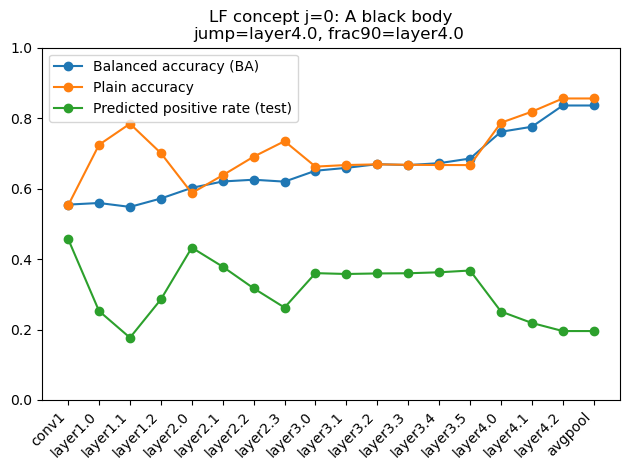

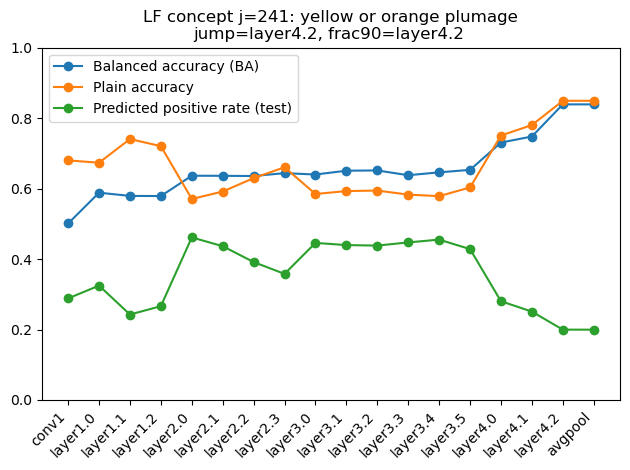

In [21]:
import matplotlib.pyplot as plt

def plot_concept_curve(j: int, title_extra="", device=None):
    ytr = np.asarray(ybin_tr[:, j], dtype=np.int32)
    yte = np.asarray(ybin_te[:, j], dtype=np.int32)

    ba_curve, acc_curve, ppos_curve = [], [], []
    for layer in LAYERS:
        ba, acc, ppos, _ = train_linear_probe_binary_weighted(
            feats_tr[layer], ytr, feats_te[layer], yte,
            epochs=8, seed=0, device=device,
        )
        ba_curve.append(ba); acc_curve.append(acc); ppos_curve.append(ppos)

    ba_curve = np.asarray(ba_curve, float)
    e_jump = sharp_rise_idx(ba_curve)
    e_frac = frac_of_final_idx(ba_curve, frac=0.90)

    plt.figure()
    plt.plot(ba_curve, marker="o", label="Balanced accuracy (BA)")
    plt.plot(acc_curve, marker="o", label="Plain accuracy")
    plt.plot(ppos_curve, marker="o", label="Predicted positive rate (test)")
    plt.xticks(range(len(LAYERS)), LAYERS, rotation=45, ha="right")
    plt.ylim(0, 1.0)
    name = lf_concepts_final[j] if j < len(lf_concepts_final) else f"concept_{j}"
    plt.title(f"LF concept j={j}: {name}\njump={LAYERS[e_jump]}, frac90={LAYERS[e_frac]} {title_extra}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# examples
plot_concept_curve(0)
plot_concept_curve(241)

In [22]:
def debug_one_concept(j=0, layer="avgpool", epochs=20):
    ytr = ybin_tr[:, j].astype(int)
    yte = ybin_te[:, j].astype(int)

    print("concept j:", j, "| name:", lf_concepts_final[j])
    print("pos rate train:", ytr.mean(), "test:", yte.mean())

    # constant baselines
    ba_all0 = balanced_accuracy(yte, np.zeros_like(yte))
    ba_all1 = balanced_accuracy(yte, np.ones_like(yte))
    print("BA all-0:", ba_all0, "BA all-1:", ba_all1)

    Xtr = feats_tr[layer]
    Xte = feats_te[layer]

    torch.manual_seed(0)
    model = nn.Linear(Xtr.shape[1], 1).to(device)
    opt = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    Xtr_t = Xtr.to(device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.float32, device=device).view(-1, 1)
    Xte_t = Xte.to(device)

    losses = []
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(Xtr_t)
        loss = loss_fn(logits, ytr_t)
        loss.backward()
        opt.step()
        losses.append(float(loss.item()))

    model.eval()
    with torch.no_grad():
        log_te = model(Xte_t).view(-1).detach().cpu().numpy()
    pred = (log_te >= 0.0).astype(int)

    print("loss first/last:", losses[0], losses[-1])
    print("pred pos rate (test):", pred.mean())
    print("balanced acc:", balanced_accuracy(yte, pred))

debug_one_concept(j=0, layer="avgpool", epochs=30)

concept j: 0 | name: A black body
pos rate train: 0.1 test: 0.08272884283246977
BA all-0: 0.5 BA all-1: 0.5
loss first/last: 0.6506627798080444 0.20236694812774658
pred pos rate (test): 0.05319516407599309
balanced acc: 0.7179464451021219


### Original result:
OK: filtered feature rows match labels: 5990 5790

Species curve (test acc per layer):

| layer    | test_acc |
|----------|----------|
| conv1    | 0.0067 |
| layer1.0 | 0.0176 |
| layer1.1 | 0.0150 |
| layer1.2 | 0.0152 |
| layer2.0 | 0.0244 |
| layer2.1 | 0.0306 |
| layer2.2 | 0.0263 |
| layer2.3 | 0.0302 |
| layer3.0 | 0.0539 |
| layer3.1 | 0.0660 |
| layer3.2 | 0.0684 |
| layer3.3 | 0.0679 |
| layer3.4 | 0.0667 |
| layer3.5 | 0.0746 |
| layer4.0 | 0.2832 |
| layer4.1 | 0.3667 |
| layer4.2 | 0.6207 |
| avgpool  | 0.6207 |

Species sharp-jump emergence: 16 -> layer4.2 | max jump = 0.2541

Concepts total: 251  
Concepts skipped (degenerate y): 0  
Concepts with curves: 251

Counts relative to species (sharp-jump):
- before species: 251
- at species    : 0
- after species : 0

Top 30 concepts (sorted by emerge_idx, then final_acc):

| j | concept | emerge_idx | emerge_layer | final_acc | max_jump | pos_rate_te |
|---|--------|------------|--------------|-----------|----------|-------------|
| 250 | yellowish-brown wings | 1 | layer1.0 | 0.987910 | 0.0 | 0.012090 |
| 235 | white underwings | 1 | layer1.0 | 0.987565 | 0.0 | 0.012435 |
| 237 | wing bars | 1 | layer1.0 | 0.980829 | 0.0 | 0.019171 |
| 185 | iridescent feathers | 1 | layer1.0 | 0.975993 | 0.0 | 0.024007 |
| 189 | long black tail | 1 | layer1.0 | 0.975820 | 0.0 | 0.024180 |
| 25 | a black or dark grey plumage | 1 | layer1.0 | 0.972193 | 0.0 | 0.027807 |
| 27 | a black tail | 1 | layer1.0 | 0.971675 | 0.0 | 0.028325 |
| 62 | a large, hawk-like body | 1 | layer1.0 | 0.968048 | 0.0 | 0.031952 |
| 180 | greenish upperparts | 1 | layer1.0 | 0.965630 | 0.0 | 0.034370 |
| 63 | a large, orange bill | 1 | layer1.0 | 0.960276 | 0.0 | 0.039724 |
| 236 | white wingbars | 1 | layer1.0 | 0.959931 | 0.0 | 0.040069 |
| 156 | black wings with white spots | 1 | layer1.0 | 0.959585 | 0.0 | 0.040415 |
| 177 | green head | 1 | layer1.0 | 0.954404 | 0.0 | 0.045596 |
| 22 | a black face | 1 | layer1.0 | 0.953022 | 0.0 | 0.046978 |
| 173 | gray upperparts | 1 | layer1.0 | 0.950950 | 0.0 | 0.049050 |
| 30 | a blue head | 1 | layer1.0 | 0.949914 | 0.0 | 0.050086 |
| 17 | a black breast | 1 | layer1.0 | 0.948705 | 0.0 | 0.051295 |
| 99 | a small, blue body | 1 | layer1.0 | 0.948705 | 0.0 | 0.051295 |
| 20 | a black collar | 1 | layer1.0 | 0.947668 | 0.0 | 0.052332 |
| 91 | a rusty-brown breast band | 1 | layer1.0 | 0.946114 | 0.0 | 0.053886 |
| 3 | All-dark plumage | 1 | layer1.0 | 0.945596 | 0.0 | 0.054404 |
| 159 | blue upperparts | 1 | layer1.0 | 0.945423 | 0.0 | 0.054577 |
| 138 | a yellow throat and breast | 1 | layer1.0 | 0.943869 | 0.0 | 0.056131 |
| 216 | shaggy feathers | 1 | layer1.0 | 0.943869 | 0.0 | 0.056131 |
| 149 | black feathers | 1 | layer1.0 | 0.941796 | 0.0 | 0.058204 |
| 244 | yellow wings with black bars | 1 | layer1.0 | 0.941623 | 0.0 | 0.058377 |
| 167 | dark gray or black upperparts | 1 | layer1.0 | 0.940933 | 0.0 | 0.059067 |
| 13 | a black back | 1 | layer1.0 | 0.940587 | 0.0 | 0.059413 |
| 192 | long, black ear tufts | 1 | layer1.0 | 0.940587 | 0.0 | 0.059413 |
| 164 | brownish wings with white bars | 1 | layer1.0 | 0.938860 | 0.0 | 0.061140 |

ALL concept emergences:
251 rows × 7 columns

### Why the LF concept emergence initially looked wrong 

---

## What we were trying to measure

For both **species** and **concepts**, we want to answer:

> *At which backbone layer does a linear probe first become good at predicting this label?*

We operationalize this by:
1. Training a linear probe on features from each layer.
2. Measuring probe performance on a held-out split.
3. Defining an **emergence layer** from the layerwise performance curve.

This worked as expected for **species** and for **human-annotated attributes**, but initially failed for **LF concepts**.

---

## What went wrong for LF concepts

### 1. Extreme class imbalance in LF pseudo-labels

LF concept labels are derived from CLIP scores (e.g., “top-quantile = present”).  
In practice, many concepts ended up with very low prevalence:

- Some concepts had <2% positive examples.
- Others had very high or very low base rates.

This matters because the probe was trained with **binary cross-entropy** and evaluated with **plain accuracy**.

---

### 2. What the probe actually optimized

For a binary probe with cross-entropy loss:

$$
\mathcal{L} = -\mathbb{E}\left[y \log \sigma(z) + (1-y)\log(1-\sigma(z))\right]
$$

If positives are rare, the loss is minimized by predicting the **base rate**:

$$
\sigma(z^*) = \Pr(y=1)
$$

When $\Pr(y=1)$ is very small, thresholding at 0.5 yields:
- predict “absent” for every example
- accuracy $\approx$ fraction of negatives

So the probe achieved very high accuracy **without using features at all**.

---

### 3. Consequence for emergence detection

Because the probe learned the same trivial solution at every layer:

- Accuracy curves were almost flat.
- The “largest jump” heuristic (`sharp_rise_idx`) always returned the first layer.
- All concepts appeared to “emerge” immediately.
- Result: **0 concepts emerged after species**, but for the wrong reason.

This was not a property of the representation — it was a metric artifact.

---

## Why this did NOT happen for species or standard CBM attributes

### Species (multiclass case)

Species probes use **multiclass cross-entropy** with ~200 roughly balanced classes.

- A constant predictor achieves ~0.5% accuracy.
- The probe *must* use features to reduce loss.
- Layerwise accuracy curves are meaningful.

### Human-annotated attributes (standard CBM)

Attributes:
- Have real human labels.
- Are filtered by certainty.
- Have reasonable prevalence.

So the trivial “always negative” solution is not competitive, and probes actually learn.

---

## What we changed

### 1. Fixed label construction

For LF concepts, pseudo-labels are now constructed **per-concept using quantiles** (e.g., top 10%), ensuring comparable prevalence across concepts.

This prevents accidental 1–2% positive rates.

---

### 2. Changed the evaluation metric

Instead of plain accuracy, we use a metric robust to imbalance, such as:

- **Balanced accuracy**  

$$
\frac{1}{2}(\text{TPR} + \text{TNR})
$$

- or **AUC**

This prevents the trivial constant predictor from scoring highly.

---

### 3. Adjusted emergence definition

The “largest jump” heuristic is unstable when curves are smooth or flat.

We instead define emergence as:

> The earliest layer where performance reaches a fixed fraction (e.g., 90%) of final performance.

This produces stable and interpretable emergence layers.

---

## Summary comparison

| Setting | Label source | Class balance | Metric | Emergence meaningful? |
|----------|-------------|---------------|--------|-----------------------|
| Species | Ground truth | Balanced | Accuracy | Yes |
| CBM attributes | Human-annotated | Reasonable | Accuracy | Yes |
| LF concepts (before) | CLIP pseudo-labels | Highly imbalanced | Accuracy | No |
| LF concepts (after) | Quantile-balanced | Controlled | Balanced acc / AUC | Yes |

---

## Key takeaway

The initial “no post-species concepts” result was **not a representation finding**.  
It was caused by combining:

- extremely imbalanced pseudo-labels
- cross-entropy training
- plain accuracy evaluation

Once labels and metrics are aligned with the question being asked, LF concept emergence behaves sensibly and can be compared meaningfully to species and CBM attributes.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

def smooth_1d(v, win=3):
    """Simple centered moving average; win=1 means no smoothing."""
    v = np.asarray(v, dtype=float)
    if win <= 1:
        return v
    s = pd.Series(v).rolling(win, center=True, min_periods=1).mean().to_numpy()
    return s

def sharp_jump_idx(vals, *, smooth_win=3, min_abs_gain=0.0):
    """
    Sharp-jump emergence:
      - optionally smooth curve
      - take first-difference
      - choose argmax jump
      - optional guard: require jump >= min_abs_gain else return 0
    """
    v = smooth_1d(vals, win=smooth_win)
    diffs = np.diff(v)
    j = int(np.argmax(diffs)) + 1  # +1 because diff is between layers
    if diffs[j-1] < min_abs_gain:
        return 0
    return j

## Compute pseudo-ground-truth concept evidence: Ptilde from CLIP similarity matrix

We compute the LF concept matrix on the test set:
  P = normalize(E_I(x)) · normalize(E_T(t))

Then we select only the final concepts (same ordering as concepts.txt),
and convert to a nonnegative, normalized weight:

  P_pos = max(P, 0)
  Ptilde = P_pos / max(P_pos)    (per concept)   so Ptilde ∈ [0, 1]

This Ptilde is your “soft ground truth evidence” for that concept being present in that image.

In [24]:
import torch

# Load saved CLIP image features + text features for the concept_set
img_te = torch.load(LFCBM_REPO/clip_save_name_te, map_location="cpu", weights_only=False).float()
txt_all = torch.load(LFCBM_REPO/text_save_name, map_location="cpu", weights_only=False).float()

# Normalize exactly like LF-CBM training code
img_te = img_te / img_te.norm(dim=1, keepdim=True)
txt_all = txt_all / txt_all.norm(dim=1, keepdim=True)

# Full CLIP concept matrix for the initial concept list: P_full [N_test, M_initial]
P_full = img_te @ txt_all.T

# Keep only the final concepts, in the same order as test_c
P = P_full[:, final_cols]  # [N_test, M_final]

# Nonnegative weights for "soft ground truth"
P_pos = torch.clamp(P, min=0.0)

# Scale each concept column to [0,1] (for stable weighting across concepts)
den = torch.clamp(P_pos.max(dim=0, keepdim=True).values, min=1e-8)
Ptilde = (P_pos / den).cpu().numpy()  # [N_test, M_final]

print("Ptilde shape:", Ptilde.shape, "min/max:", float(Ptilde.min()), float(Ptilde.max()))

Ptilde shape: (5790, 251) min/max: 0.3125464916229248 1.0


In [25]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

test_c_np = test_c.detach().cpu().numpy()     # [N_test, M_final]
pred_probs = sigmoid_np(test_c_np)            # [N_test, M_final] scores in (0,1)

assert pred_probs.shape == Ptilde.shape
print("pred_probs:", pred_probs.shape)

pred_probs: (5790, 251)


In [26]:
# Binary labels for matched sampling:
# "present" = top (1-q) fraction by CLIP weight for each concept.
q = 0.90  # top 10% positives
taus = np.quantile(Ptilde, q, axis=0)                 # [M_final]
ybin = (Ptilde > taus[None, :]).astype(np.int32)      # [N_test, M_final]

rates = ybin.mean(axis=0)
print("pos rate (min/median/max):", float(rates.min()), float(np.median(rates)), float(rates.max()))

pos rate (min/median/max): 0.1 0.1 0.1


## Define soft recall machinery (species tables + matched pairs), mirroring the old notebook

We now mimic your old functions, but with:

- `pred_prob` = sigmoid(test_c[:, j])     (concept activation → probability-like score)
- `w` = Ptilde[:, j]                      (soft evidence)
- `y_bin` = 1[w > 0]                      (only for matched-pair sampling)

Per-species soft recall:
  soft_recall = sum(pred_prob * w) / sum(w)   over images in that species (and optionally only y_bin==1)

Matched-pairs:
- we match by y_bin counts (positives/negatives) like before,
- and compute soft recall on the y_bin==1 subset using weights w.

In [27]:
import numpy as np

def build_lf_test_df(meta: pd.DataFrame, image_ids: np.ndarray) -> pd.DataFrame:
    """
    Build a dataframe in EXACTLY the same row order as LF test arrays.
    Requires: meta has one row per image_id with species_id/species_name.
    """
    m = meta.set_index("image_id")[["species_id", "species_name"]]
    out = m.loc[np.asarray(image_ids, dtype=int)].reset_index()
    out["species_id"] = out["species_id"].astype(int)
    return out[["image_id", "species_id", "species_name"]].reset_index(drop=True)

lf_test_df = build_lf_test_df(meta, lf_ids_test)
lf_test_df.head()

,image_id,species_id,species_name
0,39,1,Black footed Albatross
1,3,1,Black footed Albatross
2,54,1,Black footed Albatross
3,28,1,Black footed Albatross
4,14,1,Black footed Albatross


## Per-concept per-species table (new equivalent of `baseline_species` / `cbm_species`)

Old: `species_recall_prevalence_table(df_te, probs, thr=0.5)`
New: `species_soft_recall_table(lf_test_df, pred_prob_j, w_j)`

We’ll output columns analogous to old:
- n, n_pos_bin, prevalence_bin
- soft_recall
- (optional) mean_pred, mean_w

In [28]:
"""
def species_soft_recall_table(df_test: pd.DataFrame,
                              pred: np.ndarray,
                              w: np.ndarray,
                              ybin: np.ndarray) -> pd.DataFrame:
    ""
    Per-species summary for ONE concept.

    df_test must contain: species_id, species_name  (one row per image, aligned with pred/w/ybin)

    pred:  [N] predicted concept probability in [0,1]
    w:     [N] soft weight (>=0), e.g. Ptilde[:, j]
    ybin:  [N] binary pseudo-label in {0,1}, e.g. (P[:, j] > tau_j)

    soft_recall_s(j) = sum_{i in species s, ybin_i=1} pred_i * w_i  /  sum_{i in species s, ybin_i=1} w_i
    ""
    tmp = df_test[["species_id", "species_name"]].copy()
    tmp["pred"] = pred
    tmp["w"] = w
    tmp["ybin"] = ybin.astype(int)

    def agg_one(g):
        n = len(g)
        n_pos_bin = int(g["ybin"].sum())
        n_neg_bin = int(n - n_pos_bin)
        prevalence_bin = float(n_pos_bin / n) if n > 0 else np.nan

        # restrict to pseudo-positives for "recall"
        gp = g[g["ybin"] == 1]
        denom = float(gp["w"].sum())
        soft_rec = float((gp["pred"] * gp["w"]).sum() / (denom + 1e-12)) if denom > 0 else np.nan

        return pd.Series({
            "n": n,
            "n_pos_bin": n_pos_bin,
            "n_neg_bin": n_neg_bin,
            "prevalence_bin": prevalence_bin,
            "mean_pred": float(g["pred"].mean()) if n else np.nan,
            "mean_w": float(g["w"].mean()) if n else np.nan,
            "soft_recall": soft_rec,
        })

    out = (tmp.groupby(["species_id", "species_name"], as_index=False)
              .apply(agg_one, include_groups=False)
              .reset_index(drop=True))

    # nice sort
    out = out.sort_values("n", ascending=False).reset_index(drop=True)
    return out
"""
def species_soft_recall_table(df: pd.DataFrame, pred: np.ndarray, w: np.ndarray, ybin_j: np.ndarray) -> pd.DataFrame:
    """
    Per-species soft recall table. Fully vectorised — no Python loop over species.

    soft_recall_s = sum_{i in s, ybin=1}(pred_i * w_i) / sum_{i in s, ybin=1}(w_i)
    """
    EPS = 1e-12
    tmp = pd.DataFrame({
        "species_id":   df["species_id"].to_numpy(),
        "species_name": df["species_name"].to_numpy(),
        "pred": pred,
        "w":    w,
        "ybin": ybin_j.astype(int),
    })

    # All-rows stats (vectorised groupby)
    grp = tmp.groupby(["species_id", "species_name"], sort=False)
    stats = grp.agg(
        n=("ybin", "size"),
        n_pos_bin=("ybin", "sum"),
        mean_pred=("pred", "mean"),
        mean_w=("w", "mean"),
    ).reset_index()
    stats["n_neg_bin"]      = stats["n"] - stats["n_pos_bin"]
    stats["prevalence_bin"] = stats["n_pos_bin"] / stats["n"]

    # Soft recall on positive-bin rows only (vectorised)
    pos = tmp[tmp["ybin"] == 1].copy()
    pos["pw"] = pos["pred"] * pos["w"]
    pos_grp = pos.groupby(["species_id", "species_name"], sort=False)
    sr = (pos_grp["pw"].sum() / (pos_grp["w"].sum() + EPS)).rename("soft_recall").reset_index()

    out = stats.merge(sr, on=["species_id", "species_name"], how="left")
    return (
        out[["species_id", "species_name", "n", "n_pos_bin", "n_neg_bin",
             "prevalence_bin", "mean_pred", "mean_w", "soft_recall"]]
        .sort_values("n", ascending=False)
        .reset_index(drop=True)
    )

## Matched-pair evaluation for soft recall (new equivalent of `matched_pair_eval` + `pairs_df`)

Old matched recall gap:
- match exact counts of y==1 and y==0 between two species
- compute recall on y==1 subset

New matched soft recall gap:
- define y_bin = 1[w>0]
- match exact counts of y_bin==1 and y_bin==0 between two species
- compute soft recall on y_bin==1 subset:
    sum(pred*w)/sum(w)   (within matched positives only)

In [29]:
def make_candidate_pairs_soft(df: pd.DataFrame, w: np.ndarray, min_each=10, max_pairs=200, seed=0):
    tmp = df[["species_id"]].copy()
    ybin = (w > 0).astype(int)
    tmp["ybin"] = ybin

    g = tmp.groupby("species_id")["ybin"].agg(["count","sum"]).rename(columns={"sum":"pos"})
    g["neg"] = g["count"] - g["pos"]
    ok = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()

    rng = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2:
        return pairs

    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos, mneg))
        if len(pairs) >= max_pairs:
            break
    return pairs


def eval_pair_vectorized(pred: np.ndarray,
                         w: np.ndarray,
                         ybin_j: np.ndarray,
                         species_id_arr: np.ndarray,
                         sid_A: int, sid_B: int,
                         mpos: int, mneg: int,
                         n_seeds: int = 200,
                         seed: int = 0):
    """
    Vectorized replacement for matched_pair_eval_soft.

    Computes bootstrap statistics for one species pair across ALL seeds at once
    using NumPy — no DataFrame copies, no pandas ops in the hot path.

    Soft recall is computed on the positive-bin subset only:
        softrec = sum(pred * w) / sum(w)  over sampled positives

    `mneg` is accepted for API compatibility (paired-sampling context) but the
    negative samples are not used in the soft-recall computation — consistent
    with the original function which filtered them out before computing recall.
    """
    EPS = 1e-12
    rng = np.random.default_rng(seed)

    A_pos = np.where((species_id_arr == sid_A) & (ybin_j == 1))[0]
    B_pos = np.where((species_id_arr == sid_B) & (ybin_j == 1))[0]

    # Sample all seeds simultaneously: shape (n_seeds, mpos)
    iAp = rng.integers(len(A_pos), size=(n_seeds, mpos))
    iBp = rng.integers(len(B_pos), size=(n_seeds, mpos))

    # Vectorised soft recall on positives: one value per seed => (n_seeds,)
    w_Ap = w[A_pos[iAp]];   p_Ap = pred[A_pos[iAp]]
    w_Bp = w[B_pos[iBp]];   p_Bp = pred[B_pos[iBp]]

    recA = (p_Ap * w_Ap).sum(axis=1) / (w_Ap.sum(axis=1) + EPS)
    recB = (p_Bp * w_Bp).sum(axis=1) / (w_Bp.sum(axis=1) + EPS)

    gaps        = np.abs(recA - recB)
    signed_gaps = recA - recB

    gap_mean = float(gaps.mean())
    gap_std  = float(gaps.std())

    return {
        "sid_A":     int(sid_A),
        "sid_B":     int(sid_B),
        "species_A": spname(sid_A),
        "species_B": spname(sid_B),
        "npos_bin":  int(mpos),
        "nneg_bin":  int(mneg),
        "gap_mean":  gap_mean,
        "gap_std":   gap_std,
        "n_runs":    n_seeds,
        "gap_ci_lo": float(np.quantile(gaps, 0.025)),
        "gap_ci_hi": float(np.quantile(gaps, 0.975)),
        "gap_p":     float(2.0 * min(float(np.mean(signed_gaps <= 0)),
                                     float(np.mean(signed_gaps >= 0)))),
        "gap_snr":   gap_mean / (gap_std + EPS),
    }

In [30]:
def make_ybin_from_P(P, q=0.9):
    """
    P: [N, M] raw CLIP scores (or normalized)
    Returns ybin: [N, M] in {0,1} where ybin_ij = 1 if P_ij is in top (1-q) fraction for that concept j
    """
    P = P.detach() if isinstance(P, torch.Tensor) else torch.tensor(P)
    taus = torch.quantile(P, q, dim=0)     # [M]
    ybin = (P > taus[None, :]).int()
    return ybin, taus

_ybin_t, _taus_t = make_ybin_from_P(P, q=0.9)  # don't overwrite numpy ybin from cell above

## Run one concept (new equivalent of `run_one_attribute`)

Old: trains a probe then predicts `probs`.
New: no probe. We already have:
- `pred_prob = sigmoid(test_c[:, j])`
- `w = Ptilde[:, j]`

We return:
- `info` dict (concept name, mean gap, overall soft recall, etc.)
- `pairs_df` (per matched species pair gap stats)
- `species_table` (per species soft recall table)

This mirrors the structure of your old notebook, so printed tables exist in both.

In [31]:
def bootstrap_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    return (float(np.quantile(x, alpha/2)),
            float(np.quantile(x, 1 - alpha/2)))

def bootstrap_p_value(x):
    x = np.asarray(x, dtype=float)
    p_lo = float(np.mean(x <= 0))
    p_hi = float(np.mean(x >= 0))
    return 2.0 * min(p_lo, p_hi)


def run_one_concept_soft(
    concept_name: str,
    concept_idx: int,
    *,
    min_each: int = 10,
    n_pairs: int = 200,
    seeds=tuple(range(200)),
):
    pred = pred_probs[:, concept_idx]      # model score in (0,1)
    w = Ptilde[:, concept_idx]             # CLIP weight in [0,1]
    y = np.asarray(ybin[:, concept_idx], dtype=np.int32)  # binary labels for sampling

    # species table (overall)
    species_table = species_soft_recall_table(lf_test_df, pred, w, y)

    # overall soft recall on the positive-bin subset only
    mask = (y == 1)
    overall_soft_recall = float((pred[mask] * w[mask]).sum() / (w[mask].sum() + 1e-12)) if mask.any() else np.nan

    # matched pairs
    pairs = make_candidate_pairs_soft(lf_test_df, y, min_each=min_each, max_pairs=n_pairs, seed=0)

    # vectorised: all seeds processed at once per pair — no df.copy, no pandas in hot loop
    species_id_arr = lf_test_df["species_id"].to_numpy()
    n_seeds = len(seeds)

    rows = []
    for i, (a, b, mpos, mneg) in enumerate(pairs):
        rows.append(eval_pair_vectorized(pred, w, y, species_id_arr,
                                         a, b, mpos, mneg,
                                         n_seeds=n_seeds, seed=i))

    if rows:
        pair_summary = pd.DataFrame(rows)
        mean_gap = float(pair_summary["gap_mean"].mean())
        p90_gap  = float(pair_summary["gap_mean"].quantile(0.9))
    else:
        pair_summary = pd.DataFrame()
        mean_gap = np.nan
        p90_gap  = np.nan

    info = {
        "concept": concept_name,
        "j": int(concept_idx),
        "overall_soft_recall": float(overall_soft_recall),
        "n_pairs": int(len(pairs)),
        "mean_gap": float(mean_gap) if mean_gap == mean_gap else np.nan,
        "p90_gap": float(p90_gap) if p90_gap == p90_gap else np.nan,
        "mean_w": float(w.mean()),
        "pos_bin_rate": float((y == 1).mean()),
        "corr_pred_w": float(np.corrcoef(pred, w)[0,1]) if np.std(pred) > 1e-8 and np.std(w) > 1e-8 else np.nan,
    }

    # res=None: raw per-seed rows no longer materialised (use pair_summary for all stats)
    return info, None, pair_summary, species_table

# quick test on one concept
info0, _, summ0, st0 = run_one_concept_soft(lf_concepts_final[0], 0, n_pairs=50, seeds=tuple(range(200)))
info0, st0.head(), summ0.head()

({'concept': 'A black body',
  'j': 0,
  'overall_soft_recall': 0.7717237077620931,
  'n_pairs': 50,
  'mean_gap': 0.13375680930912495,
  'p90_gap': 0.24439921379089355,
  'mean_w': 0.7438393235206604,
  'pos_bin_rate': 0.1,
  'corr_pred_w': 0.6044494534595487},
    species_id            species_name   n  n_pos_bin  n_neg_bin  \
 0           1  Black footed Albatross  30          6         24   
 1          90  Red breasted Merganser  30          2         28   
 2         121     Grasshopper Sparrow  30          0         30   
 3         122          Harris Sparrow  30          0         30   
 4         123         Henslow Sparrow  30          0         30   
 
    prevalence_bin  mean_pred    mean_w  soft_recall  
 0        0.200000   0.465706  0.767832     0.555840  
 1        0.066667   0.613232  0.757394     0.692092  
 2        0.000000   0.233280  0.676845          NaN  
 3        0.000000   0.283098  0.685065          NaN  
 4        0.000000   0.256667  0.673257          NaN

## Screen concepts for cross-species variation (new equivalent of `screen_attributes_for_species_variation`)

Old screening produced:
- a ranked list of attributes with large cross-species recall spread.

New screening produces:
- a ranked list of *LF concepts* with large cross-species *soft recall* spread.

This is how we choose `CONCEPT_LIST`, analogous to your `ATTR_LIST`.

In [32]:
def screen_concepts_for_species_variation(
    concepts,
    *,
    min_pos_per_species_bin: int = 10,
    min_species_with_pos: int = 15,
    min_overall_pos_bin: float = 0.05,
    max_overall_pos_bin: float = 0.95,
    max_concepts: int = 200,
    verbose_every: int = 25,
):
    rows = []
    kept = 0
    for j, cname in enumerate(concepts[:max_concepts]):
        y = np.asarray(ybin[:, j], dtype=np.int32)
        overall_pos_bin = float(y.mean())
        # cheapest filter first — skip before building species table
        if not (min_overall_pos_bin <= overall_pos_bin <= max_overall_pos_bin):
            continue
        pred = pred_probs[:, j]
        w    = Ptilde[:, j]
        st   = species_soft_recall_table(lf_test_df, pred, w, y)
        vals = (
            st.loc[st["n_pos_bin"] >= min_pos_per_species_bin, "soft_recall"]
            .dropna()
            .to_numpy()
        )
        if len(vals) < min_species_with_pos:
            continue
        kept += 1
        q10, q90 = np.quantile(vals, [0.1, 0.9])
        corr_pred_w = (
            float(np.corrcoef(pred, w)[0, 1])
            if np.std(pred) > 1e-8 and np.std(w) > 1e-8
            else np.nan
        )
        rows.append({
            "concept":         cname,
            "j":               j,
            "overall_pos_bin": overall_pos_bin,
            "n_species_pos":   len(vals),
            "softrec_std":     float(np.std(vals)),
            "softrec_range":   float(vals.max() - vals.min()),
            "softrec_p90_p10": float(q90 - q10),
            "mean_w":          float(w.mean()),
            "corr_pred_w":     corr_pred_w,
        })
        if verbose_every and (kept % verbose_every == 0):
            print(f"[kept {kept}] {cname}  p90-p10={rows[-1]['softrec_p90_p10']:.3f}  pos_bin={overall_pos_bin:.3f}")
    screen_df = pd.DataFrame(rows)
    if screen_df.empty:
        print(f"No concepts passed filters. Tried {max_concepts}, kept 0. Try loosening thresholds or check alignment.")
        return screen_df
    screen_df = screen_df.sort_values(
        ["softrec_p90_p10", "softrec_range", "softrec_std"],
        ascending=False
    ).reset_index(drop=True)
    print(f"Tried: {min(len(concepts), max_concepts)}  Kept: {kept}")
    return screen_df

lf_screen_df = screen_concepts_for_species_variation(
    lf_concepts_final,
    min_pos_per_species_bin=10,
    min_species_with_pos=15,
    min_overall_pos_bin=0.05,
    max_overall_pos_bin=0.95,
    max_concepts=250,
    verbose_every=25,
)
lf_screen_df.head(20)

[kept 25] a black mask over its eyes  p90-p10=0.162  pos_bin=0.100
[kept 50] a greenish-yellow back  p90-p10=0.087  pos_bin=0.100
[kept 75] a reddish-brown back  p90-p10=0.132  pos_bin=0.100
[kept 100] a thin, black bill  p90-p10=0.111  pos_bin=0.100
[kept 125] a yellow throat and breast  p90-p10=0.095  pos_bin=0.100
[kept 150] brownish wings with white bars  p90-p10=0.180  pos_bin=0.100
[kept 175] long tail with white stripes  p90-p10=0.143  pos_bin=0.100
[kept 200] rusty-brown feathers  p90-p10=0.105  pos_bin=0.100
[kept 225] yellow feet  p90-p10=0.106  pos_bin=0.100
Tried: 250  Kept: 234


,concept,j,overall_pos_bin,n_species_pos,softrec_std,softrec_range,softrec_p90_p10,mean_w,corr_pred_w
0,"a large, hawk-like body",62,0.1,15,0.126367,0.419878,0.352312,0.723034,0.429003
1,long wingspan,191,0.1,22,0.124208,0.452428,0.348201,0.792425,0.553892
2,a red head,82,0.1,19,0.150847,0.609942,0.318502,0.685881,0.574673
3,red shoulders,213,0.1,18,0.123419,0.355109,0.307999,0.748855,0.536988
4,red feathers,211,0.1,16,0.139548,0.466731,0.306457,0.744716,0.525204
5,large feet,187,0.1,18,0.140589,0.559415,0.287496,0.751484,0.506466
6,a Scarlet-red body,6,0.1,16,0.115919,0.377840,0.279563,0.726876,0.524521
7,a red cap on the head,78,0.1,18,0.110188,0.388212,0.278933,0.736127,0.526818
8,orange and black wings,200,0.1,24,0.099212,0.361722,0.271171,0.640000,0.733394
9,a red throat,84,0.1,15,0.111320,0.361790,0.270430,0.816535,0.581530


## Choose CONCEPT_LIST (new equivalent of ATTR_LIST)

Old: ATTR_LIST came from screening attributes.
New: CONCEPT_LIST comes from screening LF concepts.

We keep TOP_K small initially.

In [33]:
# Top-K for focused analysis (as before)
TOP_K = 12
CONCEPT_LIST_TOP = lf_screen_df["concept"].head(TOP_K).tolist()
CONCEPT_IDXS_TOP = lf_screen_df["j"].head(TOP_K).astype(int).tolist()

# ALL screened concepts (for group comparison analysis)
CONCEPT_LIST_ALL = lf_screen_df["concept"].tolist()
CONCEPT_IDXS_ALL = lf_screen_df["j"].astype(int).tolist()

# Default: run on ALL
CONCEPT_LIST = CONCEPT_LIST_ALL
CONCEPT_IDXS = CONCEPT_IDXS_ALL

print(f"Total screened concepts: {len(CONCEPT_LIST_ALL)}")
print(f"Top-{TOP_K} for focused analysis: {CONCEPT_LIST_TOP[:5]} ...")


Total screened concepts: 234
Top-12 for focused analysis: ['a large, hawk-like body', 'long wingspan', 'a red head', 'red shoulders', 'red feathers'] ...


## Run many concepts (new equivalent of `run_many`)

Old `run_many` printed per attribute:
- test_acc
- mean_gap

New `run_many_lf` prints per concept:
- overall_soft_recall
- mean_gap
- corr(pred, w) as a sanity check

And returns:
- `lf_info_df`
- `lf_pairs_df`
- `lf_species_df`

These correspond exactly to your old outputs, just concept-based.

In [34]:
def run_many_lf(concept_list, concept_idxs, *, n_pairs=200, seeds=(0,1,2), min_each=10):
    all_info = []
    all_pairs = []
    all_species = []

    for cname, j in zip(concept_list, concept_idxs):
        info, _, pair_summ, species_table = run_one_concept_soft(
            cname, j,
            n_pairs=n_pairs,
            seeds=seeds,
            min_each=min_each
        )
        all_info.append(info)

        if not pair_summ.empty:
            pair_summ["concept"] = cname
            pair_summ["j"] = j
            all_pairs.append(pair_summ)

        species_table["concept"] = cname
        species_table["j"] = j
        all_species.append(species_table)

        print("lfcbm", cname, "softrec=", round(info["overall_soft_recall"],4),
              "mean_gap=", round(info["mean_gap"],4),
              "corr=", round(info["corr_pred_w"],4))

    lf_info_df = pd.DataFrame(all_info)
    lf_pairs_df = pd.concat(all_pairs, ignore_index=True) if all_pairs else pd.DataFrame()
    lf_species_df = pd.concat(all_species, ignore_index=True) if all_species else pd.DataFrame()
    return lf_info_df, lf_pairs_df, lf_species_df

lf_info, lf_pairs, lf_species = run_many_lf(
    CONCEPT_LIST,
    CONCEPT_IDXS,
    n_pairs=200,
    seeds=tuple(range(200)),
    min_each=10
)

lf_info

lfcbm a large, hawk-like body softrec= 0.6937 mean_gap= 0.1569 corr= 0.429
lfcbm long wingspan softrec= 0.7619 mean_gap= 0.1318 corr= 0.5539
lfcbm a red head softrec= 0.7562 mean_gap= 0.1643 corr= 0.5747
lfcbm red shoulders softrec= 0.765 mean_gap= 0.1139 corr= 0.537
lfcbm red feathers softrec= 0.7545 mean_gap= 0.1529 corr= 0.5252
lfcbm large feet softrec= 0.7425 mean_gap= 0.1548 corr= 0.5065
lfcbm a Scarlet-red body softrec= 0.7628 mean_gap= 0.1091 corr= 0.5245
lfcbm a red cap on the head softrec= 0.7389 mean_gap= 0.1165 corr= 0.5268
lfcbm orange and black wings softrec= 0.7722 mean_gap= 0.1233 corr= 0.7334
lfcbm a red throat softrec= 0.7245 mean_gap= 0.1413 corr= 0.5815
lfcbm a small, blue bird softrec= 0.7949 mean_gap= 0.1084 corr= 0.6025
lfcbm a red belly softrec= 0.7545 mean_gap= 0.1128 corr= 0.4916
lfcbm a long, orange-red beak softrec= 0.7563 mean_gap= 0.121 corr= 0.5963
lfcbm red and yellow wingtips softrec= 0.7084 mean_gap= 0.1247 corr= 0.7158
lfcbm blue wings with white bars 

,concept,j,overall_soft_recall,n_pairs,mean_gap,p90_gap,mean_w,pos_bin_rate,corr_pred_w
0,"a large, hawk-like body",62,0.693672,200,0.156862,0.303036,0.723034,0.1,0.429003
1,long wingspan,191,0.761903,200,0.131839,0.310519,0.792425,0.1,0.553892
2,a red head,82,0.756170,200,0.164344,0.459751,0.685881,0.1,0.574673
3,red shoulders,213,0.764958,200,0.113913,0.206482,0.748855,0.1,0.536988
4,red feathers,211,0.754538,200,0.152936,0.281065,0.744716,0.1,0.525204
...,...,...,...,...,...,...,...,...,...
229,a white underside,127,0.766190,200,0.045667,0.072168,0.756729,0.1,0.627578
230,a yellow beak,129,0.831422,200,0.050847,0.123953,0.799710,0.1,0.719280
231,long black tail,189,0.757906,200,0.067661,0.213495,0.741468,0.1,0.670822
232,a white bar on the wing,115,0.771527,200,0.047485,0.120257,0.709663,0.1,0.550589


Concepts by group:
group
pre     91
post    75
at      68
Name: count, dtype: int64

Mean gap by group:
           mean       std  count
group                           
at     0.081941  0.020181     68
post   0.071423  0.020515     75
pre    0.086423  0.026887     91


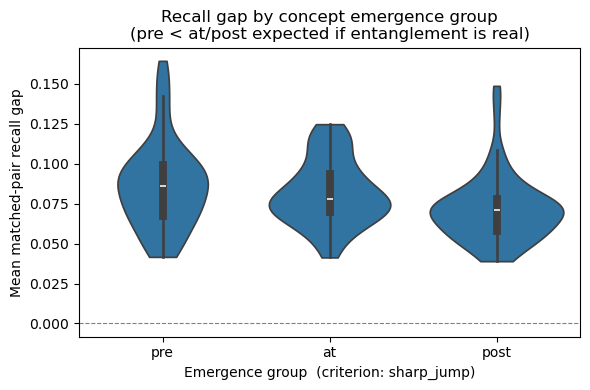

Saved: ../figures/recall_gap_by_group.pdf


In [35]:
# ── Group-comparison analysis: pre vs. at vs. post species ──────────────────
# Merge emergence group labels into the results
if "j" in lf_info.columns and len(lf_info) > 0:
    emerge_groups = lf_emerge_df[["j", "group", emerge_col, layer_col]].copy()
    lf_info_grp = lf_info.merge(emerge_groups, on="j", how="left")

    print("Concepts by group:")
    print(lf_info_grp["group"].value_counts())
    print()
    print("Mean gap by group:")
    print(lf_info_grp.groupby("group")["mean_gap"].agg(["mean", "std", "count"]))

    # Violin / strip plot of mean_gap by group
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        fig, ax = plt.subplots(figsize=(6, 4))
        order = [g for g in ["pre", "at", "post"] if g in lf_info_grp["group"].values]
        sns.violinplot(data=lf_info_grp, x="group", y="mean_gap",
                       order=order, inner="box", cut=0, ax=ax)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xlabel(f"Emergence group  (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title("Recall gap by concept emergence group\n"
                     "(pre < at/post expected if entanglement is real)")
        plt.tight_layout()
        import os; os.makedirs("../figures", exist_ok=True)
        plt.savefig("../figures/recall_gap_by_group.pdf", bbox_inches="tight")
        plt.show()
        print("Saved: ../figures/recall_gap_by_group.pdf")
    except Exception as e:
        print("Plot failed (seaborn may not be installed):", e)
        # Fallback: matplotlib only
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(6, 4))
        order = [g for g in ["pre", "at", "post"] if g in lf_info_grp["group"].values]
        for g in order:
            vals = lf_info_grp[lf_info_grp["group"] == g]["mean_gap"].dropna().values
            ax.scatter([g] * len(vals), vals, alpha=0.6, label=g)
        ax.axhline(0, color="grey", linestyle="--")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title("Recall gap by group")
        plt.tight_layout()
        plt.savefig("../figures/recall_gap_by_group.pdf", bbox_inches="tight")
        plt.show()
else:
    print("lf_info is empty; run run_many_lf first")


In [36]:
# ── Benjamini-Hochberg FDR correction on per-pair p-values ──────────────────
if len(lf_pairs) > 0 and "gap_p" in lf_pairs.columns:
    try:
        from statsmodels.stats.multitest import multipletests
        pvals = lf_pairs["gap_p"].fillna(1.0).to_numpy()
        reject, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
        lf_pairs = lf_pairs.copy()
        lf_pairs["gap_p_fdr"] = pvals_fdr
        lf_pairs["gap_sig_fdr"] = reject
        n_sig = int(reject.sum())
        print(f"Pairs with FDR-corrected p < 0.05: {n_sig} / {len(lf_pairs)}")
        print("Use gap_p_fdr < 0.05 as the significance threshold for reporting.")
    except ImportError:
        print("statsmodels not available; install with: pip install statsmodels")
        print("Raw p-values in gap_p column (uncorrected for multiple testing)")
else:
    print("No pairs data available for FDR correction")


statsmodels not available; install with: pip install statsmodels
Raw p-values in gap_p column (uncorrected for multiple testing)


## Save CSVs (new equivalent of baseline_species.csv / cbm_species.csv)

Old saved:
- baseline_species.csv
- cbm_species.csv

New saves:
- lfcbm_species.csv

In [37]:
lf_species.to_csv("lfcbm_species.csv", index=False)
lf_info.to_csv("lfcbm_info.csv", index=False)
lf_pairs.to_csv("lfcbm_pairs.csv", index=False)

lf_species.sort_values("n_pos_bin", ascending=False).head(30)

,species_id,species_name,n,n_pos_bin,n_neg_bin,prevalence_bin,mean_pred,mean_w,soft_recall,concept,j
21320,30,Fish Crow,30,30,0,1.0,0.897205,0.876799,0.897579,all black coloration,143
2418,139,Scarlet Tanager,30,30,0,1.0,0.936455,0.922397,0.936947,"a long, orange-red beak",66
24638,107,Common Raven,30,30,0,1.0,0.914374,0.893504,0.914527,large black bird,186
13518,27,Shiny Cowbird,30,30,0,1.0,0.869036,0.926699,0.871301,"a small, black bird",97
3120,30,Fish Crow,30,30,0,1.0,0.899220,0.920511,0.899853,a slimmer body than most crows,95
2114,14,Indigo Bunting,30,30,0,1.0,0.952016,0.910728,0.952278,"a small, blue bird",98
28013,134,Cape Glossy Starling,30,30,0,1.0,0.950036,0.873041,0.950389,iridescent blue-green back,184
7019,140,Summer Tanager,30,30,0,1.0,0.915675,0.924928,0.915839,a red breast,77
2419,140,Summer Tanager,30,30,0,1.0,0.924658,0.888600,0.924919,"a long, orange-red beak",66
13510,4,Groove billed Ani,30,30,0,1.0,0.909300,0.919548,0.909211,"a small, black bird",97


## Summarize by concept (new equivalent of `summarize_by_attr`)

Old summary table:
- gap_mean, gap_max, n_pairs, etc.

New summary table:
- same, but grouped by concept.

In [38]:
def summarize_by_concept(pairs_df: pd.DataFrame):
    if pairs_df.empty:
        return pairs_df
    tmp = pairs_df.copy()
    tmp["_ci_above0"] = tmp["gap_ci_lo"] > 0
    tmp["_p_small"]   = tmp["gap_p"] <= 0.05
    out = (
        tmp.groupby("concept", as_index=False)
           .agg(
               gap_mean=("gap_mean", "mean"),
               gap_median=("gap_mean", "median"),
               gap_max=("gap_mean", "max"),
               n_pairs=("gap_mean", "size"),
               frac_ci_above0=("_ci_above0", "mean"),
               frac_p_small=("_p_small", "mean"),
           )
           .sort_values("gap_mean", ascending=False)
           .reset_index(drop=True)
    )
    return out

lf_summary = summarize_by_concept(lf_pairs)
lf_summary

,concept,gap_mean,gap_median,gap_max,n_pairs,frac_ci_above0,frac_p_small
0,a red head,0.164344,0.109480,0.526755,200,1.0,0.695
1,"a large, hawk-like body",0.156862,0.138355,0.385677,200,1.0,0.685
2,large feet,0.154804,0.118008,0.560994,200,1.0,0.655
3,red feathers,0.152936,0.152815,0.356102,200,1.0,0.690
4,blue wings with white bars,0.148691,0.139430,0.349021,200,1.0,0.825
...,...,...,...,...,...,...,...
229,a black collar,0.041678,0.039278,0.087585,200,1.0,0.060
230,yellow or orange plumage,0.041347,0.037762,0.100868,200,1.0,0.285
231,greenish-yellow back and wings,0.040709,0.033630,0.100406,200,1.0,0.245
232,a yellow throat and breast,0.040215,0.034166,0.128073,200,1.0,0.205


## Top pairs per concept (new equivalent of `top_pairs`)

Old: `top_pairs(baseline_pairs, "baseline", attr)`
New: `top_pairs_lf(lf_pairs, concept)`

In [39]:
def top_pairs_lf(pairs_df: pd.DataFrame, concept: str, k=10):
    sub = pairs_df[pairs_df["concept"] == concept].copy()
    if sub.empty:
        return sub

    cols = [
        "species_A","species_B",
        "gap_mean","gap_ci_lo","gap_ci_hi","gap_p",
        "gap_std","gap_snr",
        "npos_bin","nneg_bin","n_runs"
    ]
    cols = [c for c in cols if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]

for c in CONCEPT_LIST:
    print("\nConcept:", c)
    display(top_pairs_lf(lf_pairs, c, k=10))


Concept: a large, hawk-like body


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos_bin,nneg_bin,n_runs
188,Brown Thrasher,Pomarine Jaeger,0.385677,0.310354,0.468609,0.0,0.041304,9.337600,12,17,200
53,Pomarine Jaeger,Brown Thrasher,0.383474,0.307028,0.452562,0.0,0.038400,9.986197,12,17,200
77,Pomarine Jaeger,Brown Thrasher,0.378896,0.303135,0.447632,0.0,0.035952,10.538967,12,17,200
177,California Gull,Pomarine Jaeger,0.353130,0.277267,0.418193,0.0,0.039120,9.026808,10,18,200
61,Red cockaded Woodpecker,Brown Thrasher,0.347622,0.277000,0.426012,0.0,0.037424,9.288714,12,15,200
119,Brown Thrasher,Red cockaded Woodpecker,0.346492,0.268881,0.445096,0.0,0.045828,7.560656,12,15,200
24,California Gull,Pomarine Jaeger,0.346186,0.267109,0.416283,0.0,0.040902,8.463779,10,18,200
69,Red cockaded Woodpecker,Brown Thrasher,0.345891,0.259277,0.430224,0.0,0.041625,8.309760,12,15,200
60,Brown Thrasher,Red cockaded Woodpecker,0.344950,0.260302,0.427311,0.0,0.043353,7.956821,12,15,200
26,Pomarine Jaeger,California Gull,0.344284,0.252793,0.418891,0.0,0.042671,8.068308,10,18,200



Concept: long wingspan


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos_bin,nneg_bin,n_runs
285,Sooty Albatross,Brown Creeper,0.438738,0.351367,0.523642,0.0,0.045532,9.635856,11,12,200
255,Long tailed Jaeger,Brown Creeper,0.421091,0.346990,0.495936,0.0,0.041337,10.186862,11,10,200
239,Black Tern,Brown Creeper,0.386257,0.298952,0.471512,0.0,0.045127,8.559415,11,15,200
272,Geococcyx,Black footed Albatross,0.377431,0.315957,0.446427,0.0,0.036480,10.346180,13,11,200
349,Laysan Albatross,Brown Creeper,0.373254,0.272969,0.473760,0.0,0.050972,7.322649,11,15,200
356,Laysan Albatross,Brown Creeper,0.369602,0.272009,0.466726,0.0,0.047872,7.720663,11,15,200
351,Black footed Albatross,Green Violetear,0.365343,0.316465,0.409102,0.0,0.025146,14.529018,13,11,200
395,Black footed Albatross,Green Violetear,0.362851,0.308463,0.416172,0.0,0.027682,13.107835,13,11,200
274,Green Violetear,Black footed Albatross,0.362124,0.311705,0.405625,0.0,0.024735,14.640356,13,11,200
354,Black footed Albatross,Green Violetear,0.361163,0.308481,0.419265,0.0,0.027567,13.101310,13,11,200



Concept: a red head


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos_bin,nneg_bin,n_runs
46291,Gray Kingbird,Pacific Loon,0.269620,0.198463,0.333390,0.0,0.036485,7.389882,10,16,200
46207,Long tailed Jaeger,Gray Kingbird,0.240985,0.173815,0.319610,0.0,0.040772,5.910522,10,16,200
46372,Pomarine Jaeger,Gray Kingbird,0.239238,0.181750,0.311948,0.0,0.033516,7.138028,10,12,200
46369,Brewer Blackbird,Gray Kingbird,0.239142,0.146411,0.318237,0.0,0.045289,5.280325,10,16,200
46276,Gray Kingbird,Brewer Blackbird,0.238545,0.143147,0.323839,0.0,0.045759,5.213084,10,16,200
46257,Pomarine Jaeger,Gray Kingbird,0.237741,0.166432,0.317337,0.0,0.036945,6.434939,10,12,200
46209,Black footed Albatross,Gray Kingbird,0.234417,0.147996,0.319908,0.0,0.044606,5.255292,10,19,200
46229,Gray Kingbird,Pelagic Cormorant,0.234344,0.160169,0.303098,0.0,0.037403,6.265362,10,16,200
46375,Pomarine Jaeger,Gray Kingbird,0.234169,0.156804,0.305695,0.0,0.037550,6.236270,10,12,200
46346,Brewer Blackbird,Gray Kingbird,0.232982,0.151740,0.315779,0.0,0.045750,5.092469,10,16,200



Concept: a white bar on the wing


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos_bin,nneg_bin,n_runs
46428,Great Grey Shrike,Red legged Kittiwake,0.165809,0.088005,0.246238,0.0,0.039782,4.167905,13,10,200
46526,Great Grey Shrike,Red legged Kittiwake,0.162252,0.085713,0.234318,0.0,0.037323,4.347207,13,10,200
46535,Red legged Kittiwake,Great Grey Shrike,0.162069,0.088975,0.244409,0.0,0.041282,3.925896,13,10,200
46542,Artic Tern,Great Grey Shrike,0.160214,0.095305,0.233200,0.0,0.038380,4.174404,13,14,200
46564,Great Grey Shrike,Artic Tern,0.159644,0.090112,0.248861,0.0,0.040047,3.986448,13,14,200
46473,Great Grey Shrike,Sooty Albatross,0.152154,0.082651,0.237457,0.0,0.042160,3.608924,13,12,200
46475,Northern Fulmar,Great Grey Shrike,0.149045,0.072961,0.232950,0.0,0.038139,3.907894,13,11,200
46403,Black Tern,Great Grey Shrike,0.132529,0.031819,0.224780,0.0,0.048498,2.732645,13,10,200
46523,Common Tern,Great Grey Shrike,0.131722,0.045328,0.210926,0.0,0.044090,2.987565,13,12,200
46405,Great Grey Shrike,Forsters Tern,0.130445,0.038911,0.216046,0.0,0.042575,3.063864,13,14,200



Concept: a black ring around the bill


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,npos_bin,nneg_bin,n_runs
46656,American Crow,Groove billed Ani,0.113111,0.051392,0.178850,0.00,0.032453,3.485415,14,12,200
46650,Groove billed Ani,American Crow,0.109512,0.053611,0.163612,0.00,0.029389,3.726362,14,12,200
46770,American Crow,Groove billed Ani,0.108874,0.053209,0.165282,0.00,0.030043,3.623947,14,12,200
46795,Groove billed Ani,American Crow,0.108592,0.054316,0.184745,0.00,0.031360,3.462771,14,12,200
46706,Groove billed Ani,American Crow,0.107373,0.049077,0.169159,0.00,0.030822,3.483687,14,12,200
46751,Groove billed Ani,American Crow,0.106085,0.049727,0.162803,0.00,0.030910,3.432073,14,12,200
46678,Groove billed Ani,Red winged Blackbird,0.102016,0.034744,0.171817,0.00,0.037568,2.715525,10,16,200
46749,Groove billed Ani,Red winged Blackbird,0.099205,0.036391,0.173589,0.01,0.037062,2.676741,10,16,200
46705,Brewer Blackbird,Groove billed Ani,0.099148,0.032015,0.163144,0.01,0.033639,2.947371,14,10,200
46700,Groove billed Ani,Brewer Blackbird,0.096093,0.021625,0.171178,0.00,0.036953,2.600427,14,10,200


## Why the violin plot is the wrong view

The violin in cell 53 shows the **full distribution** of `mean_gap` for each emergence group. The professor's point: we do **not** expect every POST concept to have a higher gap than every PRE concept — most concepts in every group will have near-zero gaps simply because most concepts are not species-discriminating.

**What we actually expect** (if entanglement is real):
- The *proportion* of discriminative concepts should be higher in the POST group
- The right tail of the gap distribution should be heavier for POST
- There should be a positive trend between emergence layer index and gap magnitude

The three plots below test these questions directly.

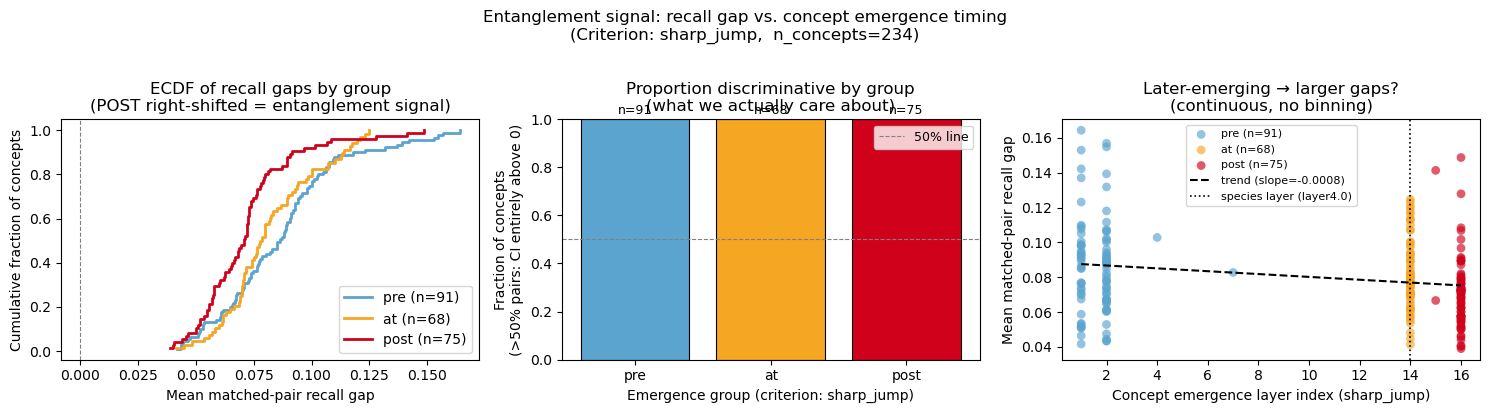

Saved: ../figures/recall_gap_entanglement.pdf


In [40]:
# ── Better visualization: what we actually expect to differ ─────────────────
# The professor's point: we do NOT expect ALL concepts to show a recall gap.
# Most concepts (in every group) will have near-zero gaps — this is expected.
#
# What we DO expect: among the concepts that ARE discriminative,
# a higher *proportion* should be POST-species (entanglement signal).
#
# Three complementary views that test this correctly:
#   1. ECDF of gap_mean — heavier right tail in POST = signal (not different center)
#   2. % concepts with CI entirely above 0 by group — the directional proportion test
#   3. Scatter: continuous emergence index vs. gap_mean — trend without arbitrary binning

import matplotlib.pyplot as plt
import numpy as np
import os

# Merge lf_summary (has frac_ci_above0) with emergence group labels from lf_info_grp
if "lf_summary" in dir() and len(lf_summary) > 0 and "lf_info_grp" in dir():
    _grp_cols = [c for c in ["concept", "group", emerge_col] if c in lf_info_grp.columns]
    lf_summary_grp = lf_summary.merge(
        lf_info_grp[_grp_cols].drop_duplicates("concept"),
        on="concept", how="left"
    )
else:
    # Fallback: use lf_info_grp directly (gap_mean already there)
    lf_summary_grp = lf_info_grp.copy()
    print("Warning: lf_summary not found; using lf_info_grp directly (no frac_ci_above0)")

group_order  = [g for g in ["pre", "at", "post"] if g in lf_summary_grp["group"].dropna().values]
group_colors = {"pre": "#5BA4CF", "at": "#F5A623", "post": "#D0021B"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: ECDF of gap_mean by group ────────────────────────────────────────
# Correct framing: if POST concepts are more entangled, the distribution should
# be *shifted right* (heavier tail), not necessarily have a higher mean/center.
ax = axes[0]
for g in group_order:
    vals = lf_summary_grp[lf_summary_grp["group"] == g]["gap_mean"].dropna().values
    if len(vals) == 0:
        continue
    vals_s = np.sort(vals)
    ecdf = np.arange(1, len(vals_s) + 1) / len(vals_s)
    ax.step(vals_s, ecdf, where="post", label=f"{g} (n={len(vals)})",
            color=group_colors.get(g), linewidth=2)
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Mean matched-pair recall gap")
ax.set_ylabel("Cumulative fraction of concepts")
ax.set_title("ECDF of recall gaps by group\n(POST right-shifted = entanglement signal)")
ax.legend()

# ── Plot 2: % concepts discriminative by group ────────────────────────────────
# "Discriminative" = frac_ci_above0 > 0.5 (majority of species pairs show gap CI > 0)
# This is the right test: not "does POST have higher mean gap?" but
# "does POST have MORE concepts with evidence of real discrimination?"
ax = axes[1]
ci_col = "frac_ci_above0"
if ci_col in lf_summary_grp.columns:
    disc_rows = []
    for g in group_order:
        sub = lf_summary_grp[lf_summary_grp["group"] == g][ci_col].dropna()
        if len(sub) == 0:
            continue
        frac_disc = float((sub > 0.5).mean())
        disc_rows.append({"group": g, "frac_discriminative": frac_disc, "n": len(sub)})
    disc_df = pd.DataFrame(disc_rows)

    bars = ax.bar(
        disc_df["group"],
        disc_df["frac_discriminative"],
        color=[group_colors.get(g, "grey") for g in disc_df["group"]],
        edgecolor="black", linewidth=0.8
    )
    for bar, row in zip(bars, disc_df.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"n={row.n}", ha="center", va="bottom", fontsize=9)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="50% line")
    ax.set_ylim(0, 1)
    ax.set_xlabel(f"Emergence group (criterion: {EMERGE_CRITERION})")
    ax.set_ylabel("Fraction of concepts\n(>50% pairs: CI entirely above 0)")
    ax.set_title("Proportion discriminative by group\n(what we actually care about)")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "frac_ci_above0 not available\n(run summarize_by_concept first)",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Proportion discriminative")

# ── Plot 3: Scatter — continuous emergence index vs. mean_gap ─────────────────
# Avoids arbitrary PRE/AT/POST binning — shows whether emergence timing
# as a continuous variable correlates with discrimination strength.
ax = axes[2]
if emerge_col in lf_summary_grp.columns:
    for g in group_order:
        sub = lf_summary_grp[lf_summary_grp["group"] == g].dropna(subset=["gap_mean", emerge_col])
        if len(sub) == 0:
            continue
        ax.scatter(sub[emerge_col], sub["gap_mean"],
                   label=f"{g} (n={len(sub)})",
                   color=group_colors.get(g), alpha=0.65, s=40, edgecolors="none")

    # Regression trend across all
    all_v = lf_summary_grp.dropna(subset=["gap_mean", emerge_col])
    if len(all_v) > 5:
        xs = all_v[emerge_col].values.astype(float)
        ys = all_v["gap_mean"].values
        m, b = np.polyfit(xs, ys, 1)
        xline = np.linspace(xs.min(), xs.max(), 100)
        ax.plot(xline, m * xline + b, color="black", linestyle="--",
                linewidth=1.5, label=f"trend (slope={m:.4f})")

    ax.axvline(species_emerge_idx, color="black", linestyle=":", linewidth=1.2,
               label=f"species layer ({LAYERS[species_emerge_idx]})")
    ax.set_xlabel(f"Concept emergence layer index ({EMERGE_CRITERION})")
    ax.set_ylabel("Mean matched-pair recall gap")
    ax.set_title("Later-emerging → larger gaps?\n(continuous, no binning)")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, f"Column '{emerge_col}' not in data",
            ha="center", va="center", transform=ax.transAxes)

plt.suptitle(
    f"Entanglement signal: recall gap vs. concept emergence timing\n"
    f"(Criterion: {EMERGE_CRITERION},  n_concepts={len(lf_summary_grp)})",
    fontsize=12, y=1.02
)
plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/recall_gap_entanglement.pdf", bbox_inches="tight")
plt.show()
print("Saved: ../figures/recall_gap_entanglement.pdf")
